# Fraud Detection Model Analysis

  **Objective**: Develop the best-performing model to detect fraudulent credit card transactions.


  **Dataset**: Kaggle Credit Card Fraud Detection (284,807 transactions, 492 frauds)

  **Primary Metric**: PR-AUC (Precision-Recall Area Under Curve) - standard for imbalanced classification
  
  **Approach**:
  1. Data quality assessment and preprocessing
  2. Systematic model comparison (LogReg, Random Forest, XGBoost)
  3. Resampling strategy evaluation (No resampling, RUS, ROS, SMOTE)
  4. Hyperparameter tuning of best model
  5. Final model selection and export

# 1. Data Loading & Initial Exploration (Setup and Imports)

## 1.1 Import libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import mannwhitneyu, ttest_ind

# Resampling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics
from sklearn.metrics import (
    roc_auc_score, classification_report, precision_recall_curve, auc, 
    precision_score, average_precision_score, recall_score, f1_score, 
    confusion_matrix, accuracy_score, roc_curve, precision_recall_curve,
)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay



import time
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.2 Load data

In [2]:
# Load the dataset
df = pd.read_csv('../data/creditcard.csv')

## 1.3 Class distribution

In [3]:
# Explore the basic info/ features in the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

As can see there are no non-null values

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

# 2. Data Quality Assessment
  
  Check for: 
- Missing values
- Duplicates
- Class imbalance
- Outliers

## 2.1 Class Distribution
Checking the fraud to non-fraud ratio

In [7]:
# Class value counts
# Count the occurrences of fraud and no fraud and print them
occ = df['Class'].value_counts()
print(occ)

# Print the ratio of fraud cases
print(occ / len(df['Class']))

# The classes are heavily skewed, show the ratio of fraud cases
print('\nNo Frauds:', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds:', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: count, dtype: float64

No Frauds: 99.83 % of the dataset
Frauds: 0.17 % of the dataset


## 2.2 Duplicates Analysis

In [8]:
# Check for duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")
print(f"Percentage of duplicates: {(n_duplicates / len(df)) * 100:.4f}%")

if n_duplicates > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 1081
Percentage of duplicates: 0.3796%

Sample duplicate rows:
      Time        V1        V2        V3        V4        V5        V6  \
32    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
33    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
34    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
35    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
112   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
113   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
114   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
115   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
220  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   
221  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   

           V7        V8        V9  ...       V21       V22       V23  \
32   0.711206  0.176066 

Next, I want to examine whether the duplicate entries are equally distributed among the regular transactions and the frauds. This will determine their relevance and importance.

In [9]:
# Analyze duplicates by class (important for fraud detection)
print("Duplicates by class:")
normal_dups = df[df['Class'] == 0].duplicated().sum()
fraud_dups = df[df['Class'] == 1].duplicated().sum()

print(f"Normal: {normal_dups:,} ({normal_dups/len(df[df['Class']==0])*100:.2f}%)")
print(f"Fraud: {fraud_dups:,} ({fraud_dups/len(df[df['Class']==1])*100:.2f}%)")

print(f"\nNormal transactions: {normal_dups:,} duplicate values "
          f"out of {df[df['Class'] == 0].shape[0]} ({normal_dups / df[df['Class'] == 0].shape[0] * 100:.2f}%)")
print(f"Fraud transactions: {fraud_dups:,} duplicate values "
          f"out of {df[df['Class'] == 1].shape[0]} ({fraud_dups / df[df['Class'] == 1].shape[0] * 100:.2f}%)")

Duplicates by class:
Normal: 1,062 (0.37%)
Fraud: 19 (3.86%)

Normal transactions: 1,062 duplicate values out of 284315 (0.37%)
Fraud transactions: 19 duplicate values out of 492 (3.86%)


**Decision rationale**:
<br></br>
Why it would be good to remove duplicates?
- **Small percentage of each class** -> minimal impact on dataset (0.38% thus safe to remove)
- **Data integrity**: inflates counts and distorts statistics
- **Model training**: avoid overfitting and data leakage if transaction appears in both train and test sets
<br><br/>

Why would it be bad to remove the duplicates:
- Can represent **legitimate repeated transactions**

**Decision**: Remove duplicates

## 2.3 Duplicate Removal

In [10]:
# Store original df with dupliates
df_raw = df.copy()

# Remove duplicates, create cleaned df without duplicates
df = df.drop_duplicates().copy()

## 2.4 Class distribution visualisation

In [15]:
print(f"Original shape: {df_raw.shape}")
print(f"Cleaned shape: {df.shape}")

print(f"\nRemoved {len(df_raw) - len(df):,} duplicate rows")
print(f"Original: {df_raw.shape[0]:,} → Cleaned: {df.shape[0]:,}")

# Update class distribution
before_counts = df_raw['Class'].value_counts()
after_counts = df['Class'].value_counts()

    
print(f"\nClass distribution impact:")
print(f"  Normal: {before_counts[0]:,} → {after_counts[0]:,}")
print(f"  Duplicates Removed: {before_counts[0] - after_counts[0]:,} ({(before_counts[0] - after_counts[0])/before_counts[0]*100:.2f}%)\n")

print(f"  Fraud:  {before_counts[1]:,} → {after_counts[1]:,}")
print(f"  Duplicates Removed: {before_counts[1] - after_counts[1]:,} ({(before_counts[1] - after_counts[1])/before_counts[1]*100:.2f}%)\n")

print(f"  Imbalance ratio: {before_counts[0]/before_counts[1]:.1f}:1 → {after_counts[0]/after_counts[1]:.1f}:1\n")

print(f"  Fraud rate (with duplicates): {df_raw['Class'].mean() * 100:.2f}%")
print(f"  Fraud rate (without duplicates): {df['Class'].mean() * 100:.2f}%")


Original shape: (284807, 31)
Cleaned shape: (283726, 31)

Removed 1,081 duplicate rows
Original: 284,807 → Cleaned: 283,726

Class distribution impact:
  Normal: 284,315 → 283,253
  Duplicates Removed: 1,062 (0.37%)

  Fraud:  492 → 473
  Duplicates Removed: 19 (3.86%)

  Imbalance ratio: 577.9:1 → 598.8:1

  Fraud rate (with duplicates): 0.17%
  Fraud rate (without duplicates): 0.17%


Removing the duplicates slightly increases the imbalance ratio
<br></br>
Since the duplicates in the original dataset primarily consisted of non-fraudulent records. When these identical majority class samples were removed, the total count of majority class instances decreased more significantly relative to the minority class, thus **slightly skewing the data to be more imbalanced.**

# 3. Exploratory Data Analysis (EDA)

Key analyses:
- Feature correlations with fraud
- Distribution differences between classes
- Statistical significance of differences

## 3.1 Class Distribution Visualization

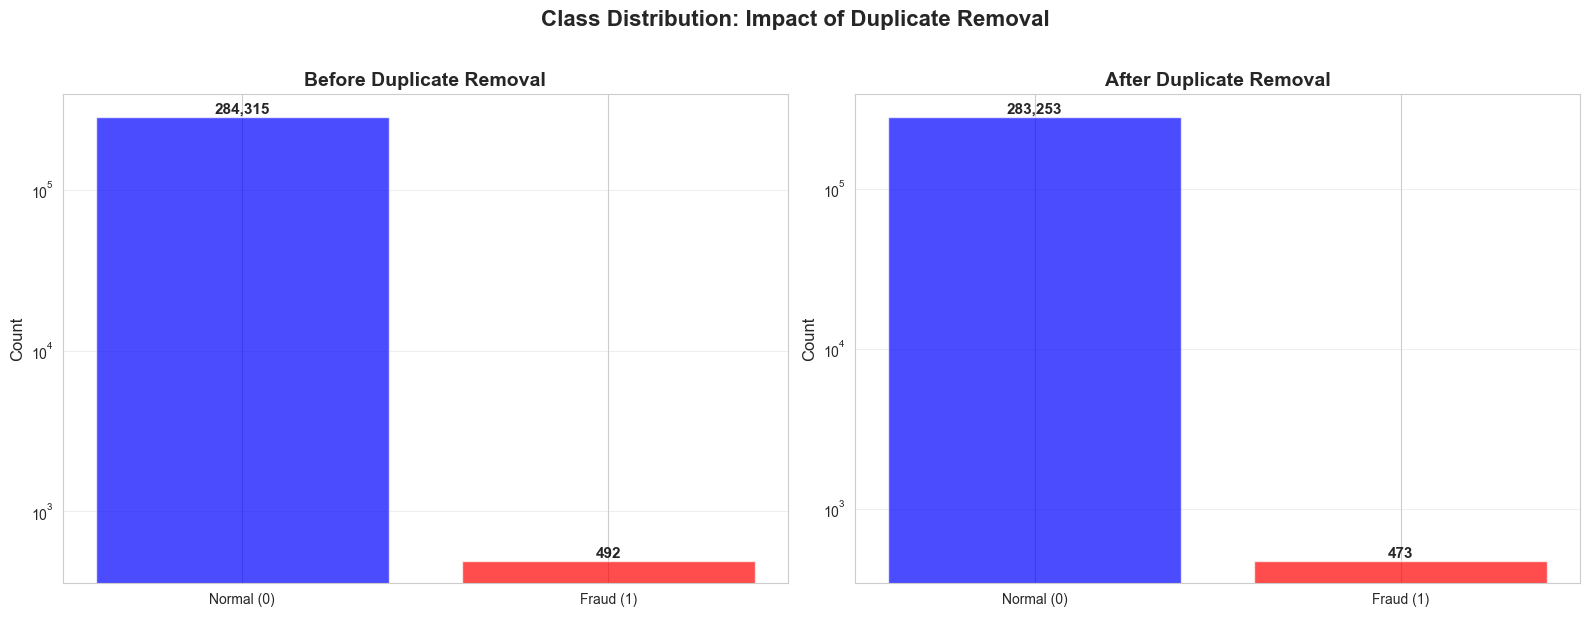

In [16]:
# Class Distribution: Before vs After Duplicate Removal

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Before cleaning
axes[0].bar(['Normal (0)', 'Fraud (1)'], before_counts.values, 
            color=['blue', 'red'], alpha=0.7)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Before Duplicate Removal', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')  # Log scale for visibility
axes[0].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(before_counts.values):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

# Right: After cleaning
axes[1].bar(['Normal (0)', 'Fraud (1)'], after_counts.values, 
            color=['blue', 'red'], alpha=0.7)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('After Duplicate Removal', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(after_counts.values):
    axes[1].text(i, count, f'{count:,}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution: Impact of Duplicate Removal', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3.2 Feature Correlations

In [18]:
# Total correlation with Class
# Calculate the correlation matrix
corr_matrix = df.corr()

# Get correlations with the 'Class' column
class_corr = corr_matrix['Class'].drop('Class')

# Sort correlations by absolute value in descending order
sorted_class_corr = class_corr.reindex(class_corr.abs().sort_values(ascending=False).index)

# Print the sorted correlations
print("Correlation with 'Class' (sorted by absolute value):\n", sorted_class_corr)


Correlation with 'Class' (sorted by absolute value):
 V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V11       0.149067
V4        0.129326
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V2        0.084624
V6       -0.043915
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
Time     -0.012359
V28       0.009682
V24      -0.007210
V23      -0.006333
Amount    0.005777
V22       0.004887
V26       0.004265
V13      -0.003897
V15      -0.003300
V25       0.003202
Name: Class, dtype: float64


In [19]:
# Top and Bottom 10 features correlation analysis with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features most correlated with Class:")
print(correlations.head(11))  # 11 because Class will be first with correlation 1.0

print("\nBottom 10 features least correlated with Class:")
print(correlations.tail(10))


Top 10 features most correlated with Class:
Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64

Bottom 10 features least correlated with Class:
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


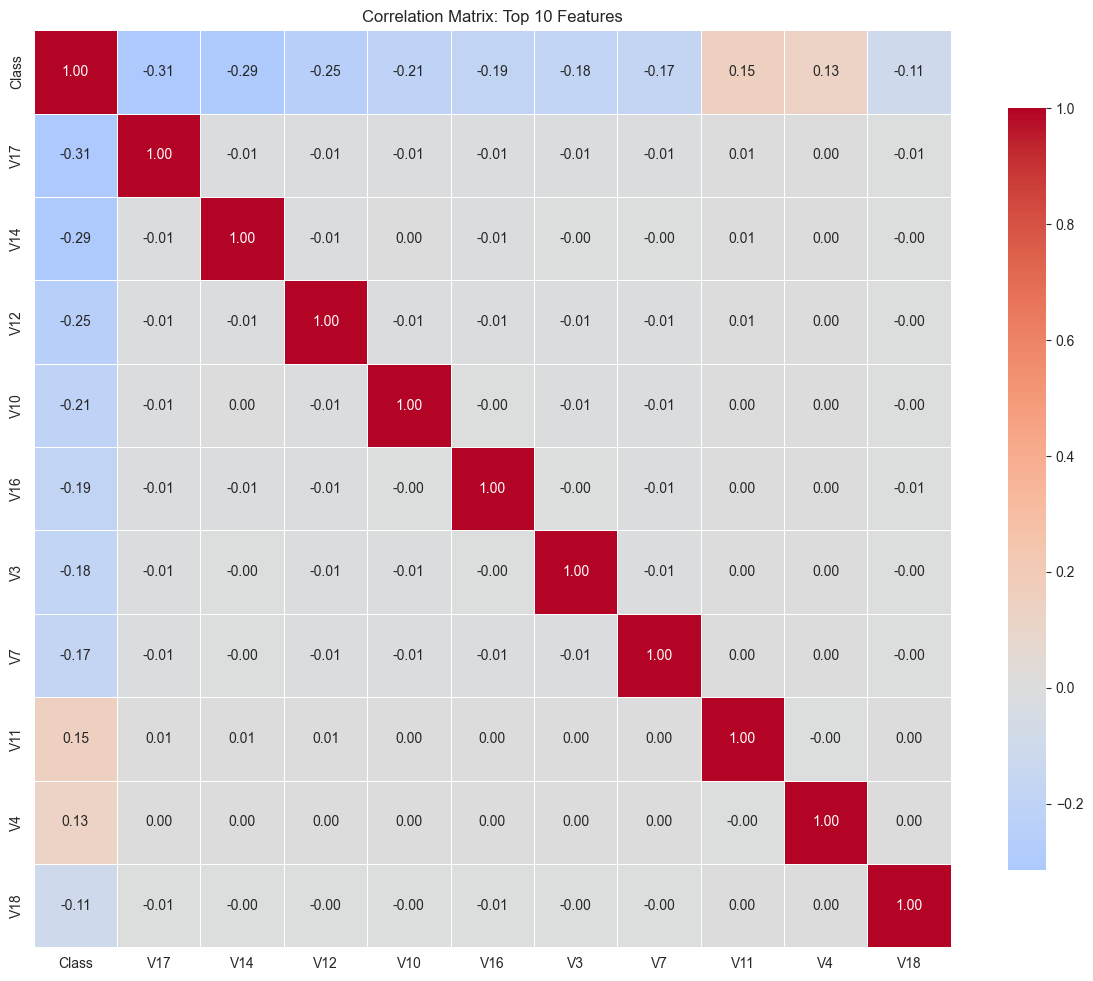

In [20]:
# Correlation heatmap for top features
top_features = correlations.abs().nlargest(11).index.tolist()  # Include Class
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title(f'Correlation Matrix: Top 10 Features')
plt.tight_layout()
plt.show()


## 3.3 Feature Distributions

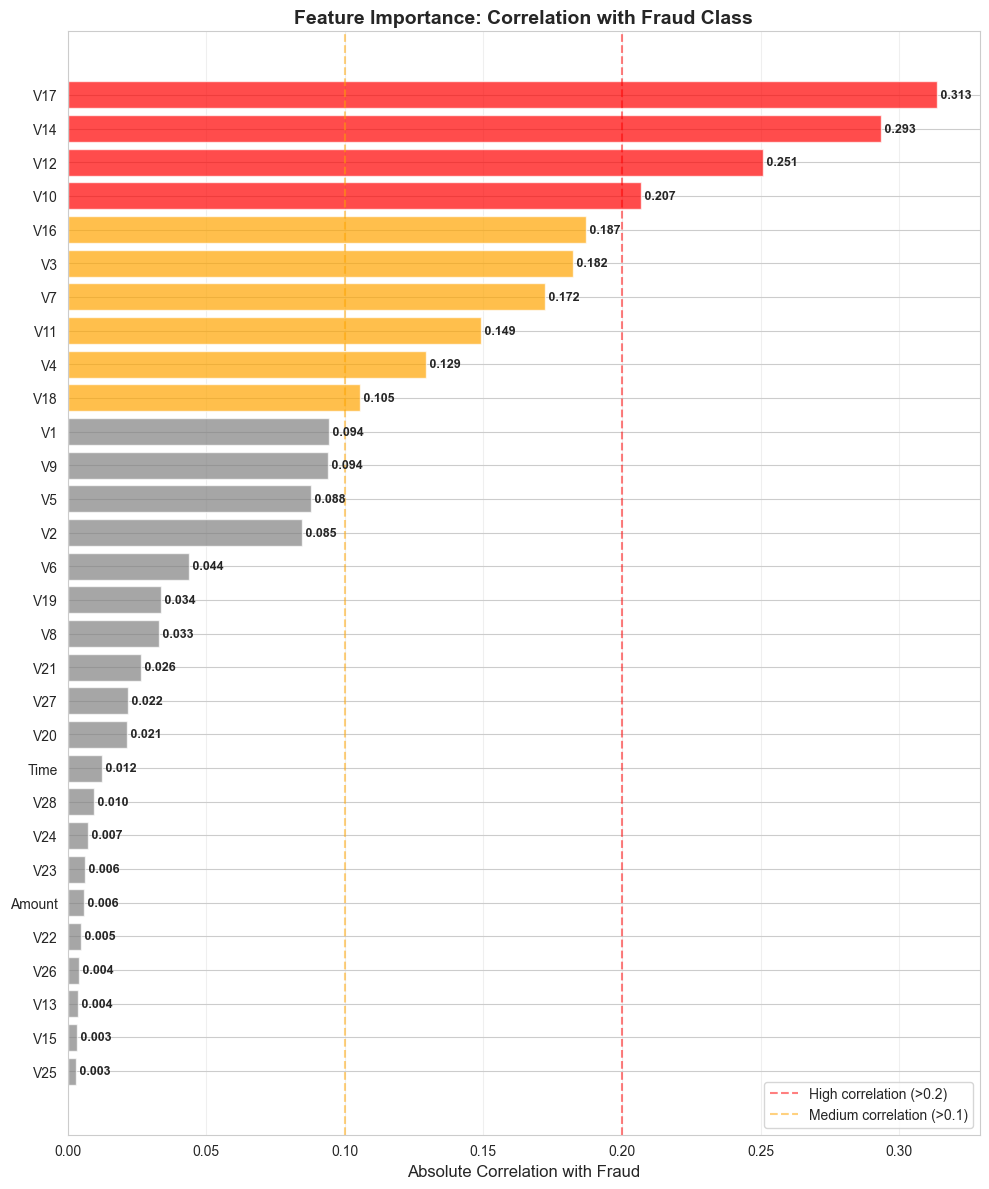


Top 5 Most Important Features for Fraud Detection:
V16    0.187186
V10    0.206971
V12    0.250711
V14    0.293375
V17    0.313498
Name: Class, dtype: float64


In [21]:
# ============================================================================
# Feature Importance Ranking (Correlation with Fraud)
# ============================================================================

correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=True)

plt.figure(figsize=(10, 12))
colors = ['red' if abs(df.corr()['Class'][feat]) > 0.2 else 'orange' if abs(df.corr()['Class'][feat]) > 0.1 else 'gray' 
          for feat in correlations.index]

bars = plt.barh(correlations.index, correlations.values, color=colors, alpha=0.7)
plt.xlabel('Absolute Correlation with Fraud', fontsize=12)
plt.title('Feature Importance: Correlation with Fraud Class', fontsize=14, fontweight='bold')
plt.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='High correlation (>0.2)')
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Medium correlation (>0.1)')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, correlations.values)):
    plt.text(val, i, f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features for Fraud Detection:")
print(correlations.tail(5))

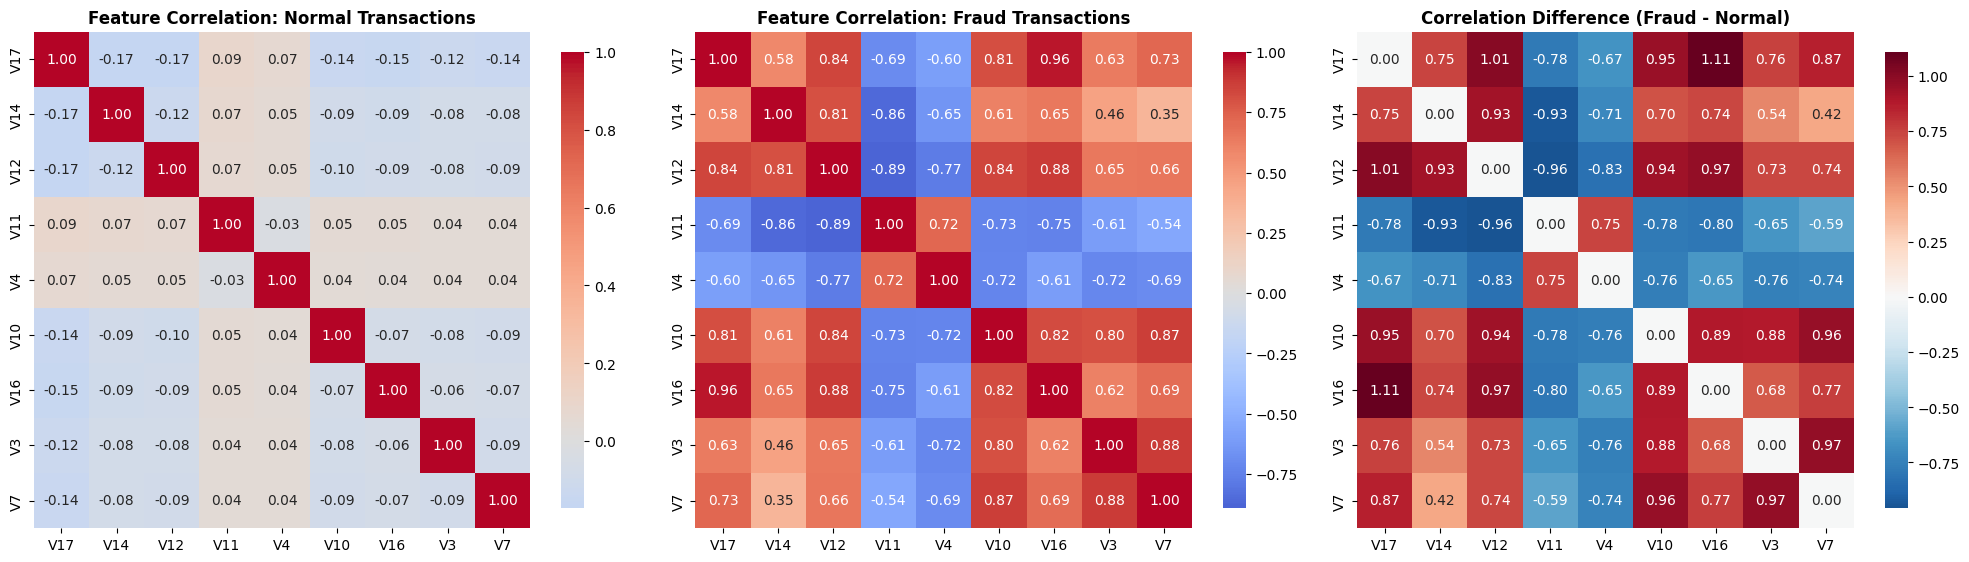

In [ ]:
# ============================================================================
# Feature Interaction Analysis
# ============================================================================

# Select top correlated features
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3', 'V7']

# Calculate interaction: correlation between features for fraud vs normal
normal_corr = df[df['Class'] == 0][top_features].corr()
fraud_corr = df[df['Class'] == 1][top_features].corr()
interaction_diff = fraud_corr - normal_corr

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Normal transactions correlation
sns.heatmap(normal_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title('Feature Correlation: Normal Transactions', fontsize=12, fontweight='bold')

# Fraud transactions correlation
sns.heatmap(fraud_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Feature Correlation: Fraud Transactions', fontsize=12, fontweight='bold')

# Difference (shows how relationships change)
sns.heatmap(interaction_diff, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[2], cbar_kws={"shrink": 0.8})
axes[2].set_title('Correlation Difference (Fraud - Normal)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3.4 Statistical Significance

/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3426274676.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True,


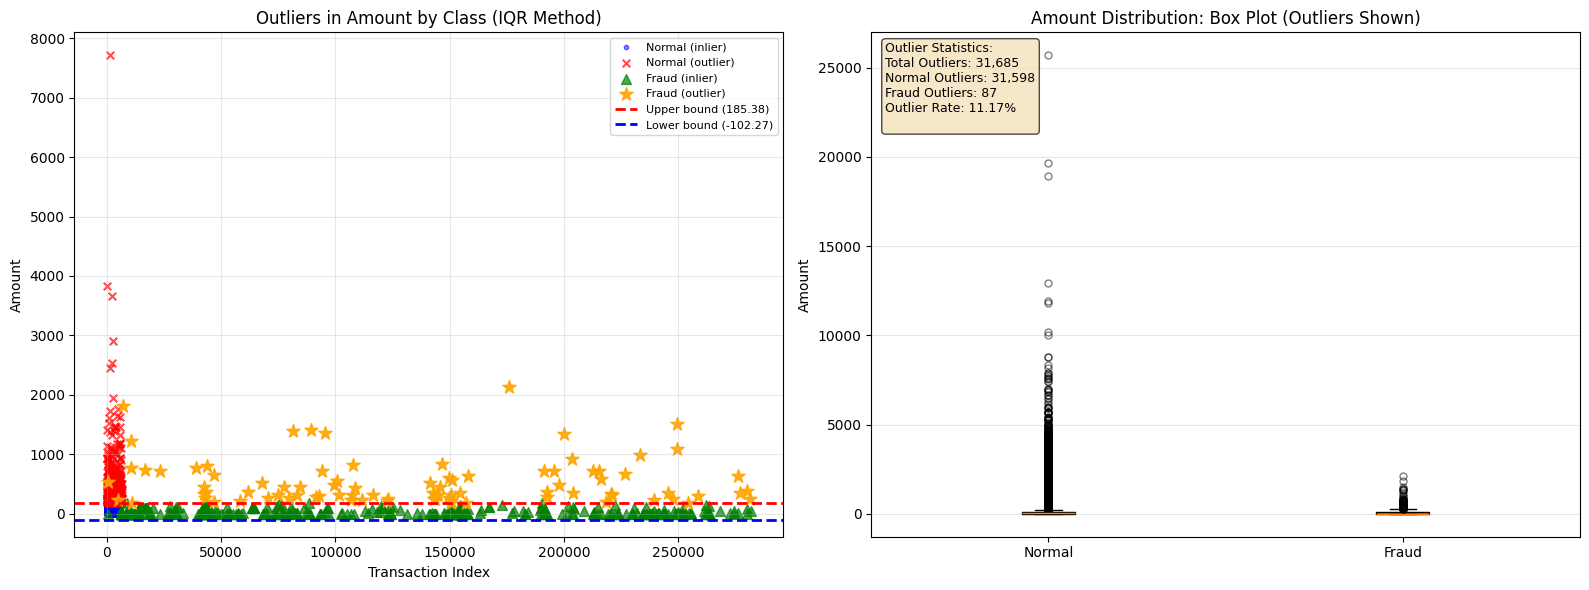

In [ ]:
# Visualize outliers detected by IQR method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate IQR bounds for Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mark outliers
df['is_outlier'] = (df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)

# Plot 1: Scatter plot showing outliers by Class
normal_inliers = df[(df['Class'] == 0) & (~df['is_outlier'])].head(5000)
normal_outliers = df[(df['Class'] == 0) & (df['is_outlier'])].head(500)
fraud_inliers = df[(df['Class'] == 1) & (~df['is_outlier'])]
fraud_outliers = df[(df['Class'] == 1) & (df['is_outlier'])]

axes[0].scatter(normal_inliers.index, normal_inliers['Amount'], 
                alpha=0.5, label='Normal (inlier)', color='blue', s=10)
axes[0].scatter(normal_outliers.index, normal_outliers['Amount'], 
                alpha=0.7, label='Normal (outlier)', color='red', s=30, marker='x')
axes[0].scatter(fraud_inliers.index, fraud_inliers['Amount'], 
                alpha=0.7, label='Fraud (inlier)', color='green', s=50, marker='^')
axes[0].scatter(fraud_outliers.index, fraud_outliers['Amount'], 
                alpha=0.9, label='Fraud (outlier)', color='orange', s=100, marker='*')

axes[0].axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, 
                label='Upper bound ({:.2f})'.format(upper_bound))
axes[0].axhline(y=lower_bound, color='blue', linestyle='--', linewidth=2, 
                label='Lower bound ({:.2f})'.format(lower_bound))
axes[0].set_xlabel('Transaction Index')
axes[0].set_ylabel('Amount')
axes[0].set_title('Outliers in Amount by Class (IQR Method)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot with outliers highlighted
box_data = [df[df['Class'] == 0]['Amount'], df[df['Class'] == 1]['Amount']]
bp = axes[1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True, 
                     showfliers=True, flierprops=dict(marker='o', markersize=5, alpha=0.5))

# Color the boxes
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

axes[1].set_ylabel('Amount')
axes[1].set_title('Amount Distribution: Box Plot (Outliers Shown)')
axes[1].grid(True, alpha=0.3, axis='y')

# Add statistics text
total_outliers = df['is_outlier'].sum()
normal_outlier_count = (df['is_outlier'] & (df['Class'] == 0)).sum()
fraud_outlier_count = (df['is_outlier'] & (df['Class'] == 1)).sum()
outlier_rate = df['is_outlier'].mean() * 100

outlier_stats = """Outlier Statistics:
Total Outliers: {:,}
Normal Outliers: {:,}
Fraud Outliers: {:,}
Outlier Rate: {:.2f}%
""".format(total_outliers, normal_outlier_count, fraud_outlier_count, outlier_rate)

axes[1].text(0.02, 0.98, outlier_stats, transform=axes[1].transAxes,
            fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('is_outlier', axis=1, inplace=True)


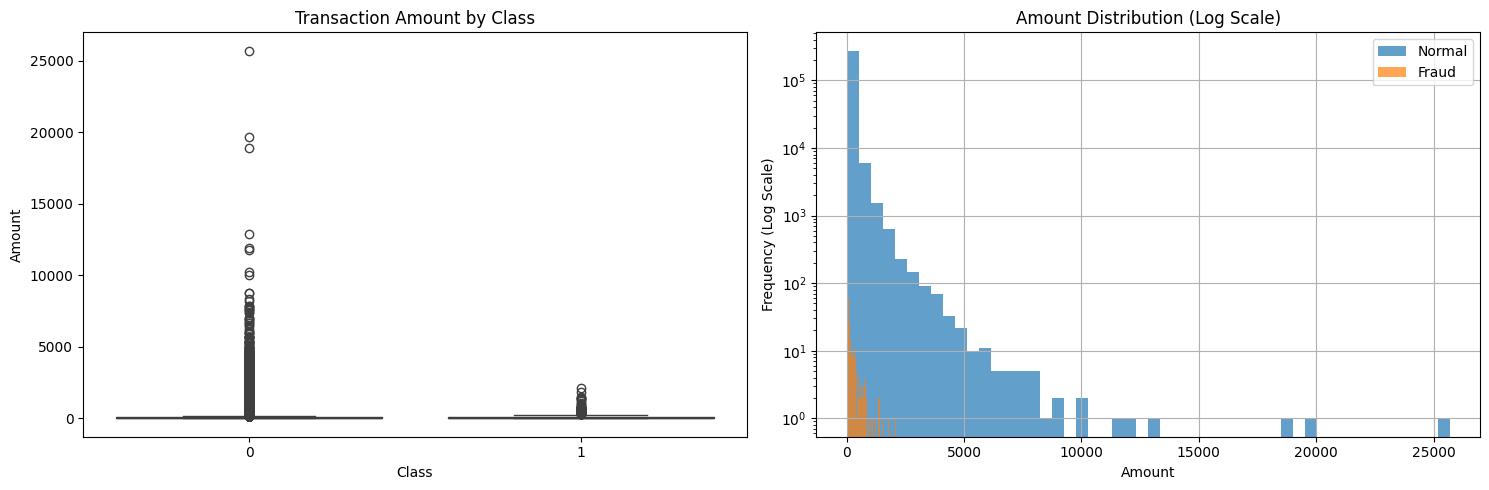


Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [ ]:
# Distribution of Amount by Class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Amount')

# Log scale histogram
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.7, label='Normal', ax=axes[1], log=True)
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', ax=axes[1], log=True)
axes[1].set_title('Amount Distribution (Log Scale)')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency (Log Scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics
print("\nAmount statistics by class:")
print(df.groupby('Class')['Amount'].describe())


## 3.5 Amount/Time analysis

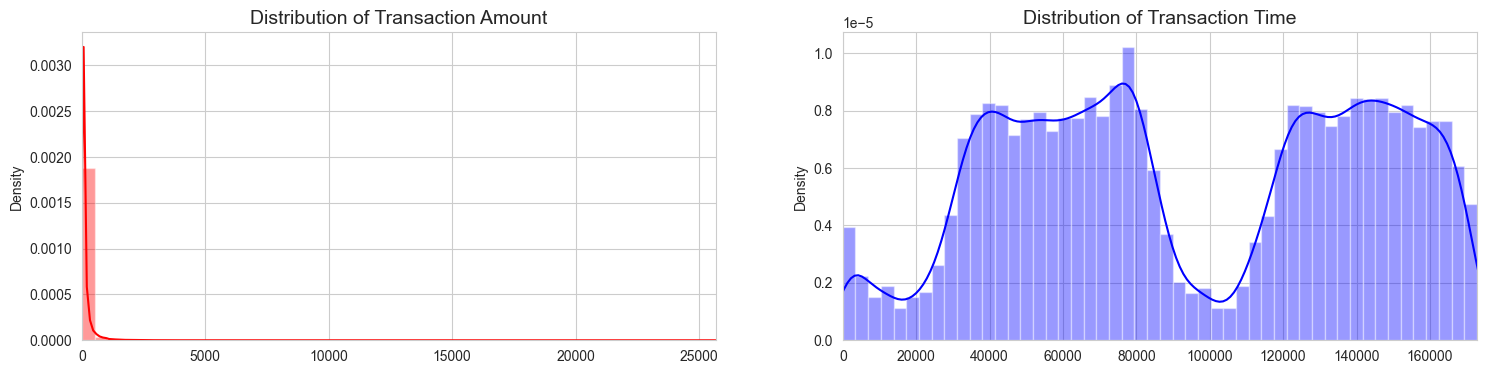

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])



plt.show()

# 4. Preprocessing

Steps:
1. Train/Test split (80/20, stratified)
2. Feature scaling (StandardScaler for Time & Amount)
3. Resampling methods for comparison

## 4.1 Train/Test Split

In [22]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts())
print(f"\nFeatures: {list(X.columns)}")

Feature matrix shape: (283726, 30)
Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [23]:
# Train/Test Split
# Split into train and test sets (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"  Fraud rate: {y_train.mean() * 100:.2f}%")

print(f"\nTest set class distribution:")
print(y_test.value_counts())
print(f"  Fraud rate: {y_test.mean() * 100:.2f}%")

print(f"\n✓ Split completed successfully!")
print(f"  Training samples: {len(X_train):,}")
print(f"  Test samples: {len(X_test):,}")


Training set shape: (226980, 30)
Test set shape: (56746, 30)

Training set class distribution:
Class
0    226602
1       378
Name: count, dtype: int64
  Fraud rate: 0.17%

Test set class distribution:
Class
0    56651
1       95
Name: count, dtype: int64
  Fraud rate: 0.17%

✓ Split completed successfully!
  Training samples: 226,980
  Test samples: 56,746


## 4.2 Feature Scaling Comparison
StandardScaler vs RobustScaler

We'll compare both scalers to determine which performs better for our fraud detection task.
In theory and accordance to the models we aim to use (Logistic Regression, Random Forest, XGBoost), since the tree based models are scale-invariant, we should only test the scalers for Logistic Regression.

This notebook aims to test various model types:

- Gradient-based (LogReg)	-> use Standard/Robust Scaler
    - **Why**: Gradient descent converges faster with standardized features	
- Tree-based (RF, XGB) -> No Scaler
    - **Why**: Splits on thresholds, rank-invariant

EDA revealed 11.2% outliers in Amount with extreme skew (max/median = 77×). 

**Results**:

Empirical validation showed <0.1% performance difference between scalers, consistent with the dominance of pre-scaled PCA features (V1–V28).	

In [24]:
# Check for outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Check outliers for Amount (most likely to have outliers)
amount_outliers = detect_outliers_iqr(df, 'Amount')
print(f"Number of outliers in Amount: {len(amount_outliers)}")
print(f"Percentage: {(len(amount_outliers) / len(df)) * 100:.2f}%")
print(f"\nOutlier statistics for Amount:")
print(amount_outliers['Amount'].describe())

Number of outliers in Amount: 31685
Percentage: 11.17%

Outlier statistics for Amount:
count    31685.000000
mean       512.929099
std        586.838556
min        185.380000
25%        240.000000
50%        335.430000
75%        552.100000
max      25691.160000
Name: Amount, dtype: float64


In [27]:
# Scaling Comparison: No Scaling vs StandardScaler vs RobustScaler
# Note: V1-V28 are already PCA components (standardized), only Time & Amount need scaling

# Features to scale
features_to_scale = ['Time', 'Amount']

# Option 1: No Scaling (baseline)
X_train_no_scale = X_train.copy()
X_test_no_scale = X_test.copy()

# Option 2: StandardScaler (only Time & Amount)
standard_scaler = StandardScaler()
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[features_to_scale] = standard_scaler.fit_transform(X_train[features_to_scale])
X_test_std[features_to_scale] = standard_scaler.transform(X_test[features_to_scale])

# Option 3: RobustScaler (only Time & Amount)
robust_scaler = RobustScaler()
X_train_rob = X_train.copy()
X_test_rob = X_test.copy()

X_train_rob[features_to_scale] = robust_scaler.fit_transform(X_train[features_to_scale])
X_test_rob[features_to_scale] = robust_scaler.transform(X_test[features_to_scale])

# Verification
print("="*70)
print("SCALING COMPARISON: Three Options Created")
print("="*70)
print(f"\n✓ V1-V28: Kept as-is (already standardized PCA components)")
print(f"✓ Only Time and Amount are scaled in Options 2 & 3\n")

print("Option 1: No Scaling")
print(f"  Time:   Mean={X_train_no_scale['Time'].mean():.2f},   Std={X_train_no_scale['Time'].std():.2f}")
print(f"  Amount: Mean={X_train_no_scale['Amount'].mean():.2f}, Std={X_train_no_scale['Amount'].std():.2f}")

print("\nOption 2: StandardScaler (Time & Amount)")
print(f"  Time:   Mean={X_train_std['Time'].mean():.6f},   Std={X_train_std['Time'].std():.6f}")
print(f"  Amount: Mean={X_train_std['Amount'].mean():.6f}, Std={X_train_std['Amount'].std():.6f}")

print("\nOption 3: RobustScaler (Time & Amount)")
print(f"  Time:   Median={X_train_rob['Time'].median():.6f},   IQR-based")
print(f"  Amount: Median={X_train_rob['Amount'].median():.6f}, IQR-based")
print("="*70)

SCALING COMPARISON: Three Options Created

✓ V1-V28: Kept as-is (already standardized PCA components)
✓ Only Time and Amount are scaled in Options 2 & 3

Option 1: No Scaling
  Time:   Mean=94900.22,   Std=47488.21
  Amount: Mean=88.39, Std=245.77

Option 2: StandardScaler (Time & Amount)
  Time:   Mean=-0.000000,   Std=1.000002
  Amount: Mean=0.000000, Std=1.000002

Option 3: RobustScaler (Time & Amount)
  Time:   Median=0.000000,   IQR-based
  Amount: Median=0.000000, IQR-based


### 4.2.1 Compare Scalers Using Logistic Regression

We'll use Logistic Regression as a baseline to compare scaler performance.



In [28]:
# Quick scaling comparison with Logistic Regression only
scaling_results = {}

# Test each scaling option
scaling_options = {
    'No Scaling': (X_train_no_scale, X_test_no_scale),
    'StandardScaler': (X_train_std, X_test_std),
    'RobustScaler': (X_train_rob, X_test_rob)
}

for name, (X_tr, X_te) in scaling_options.items():
    model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    model.fit(X_tr, y_train)
    
    y_proba = model.predict_proba(X_te)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    
    scaling_results[name] = {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
# Display results
results_df = pd.DataFrame(scaling_results).T
print("Scaling Comparison Results:")
print(results_df.sort_values('PR-AUC', ascending=False))

Scaling Comparison Results:
                 ROC-AUC    PR-AUC
StandardScaler  0.965839  0.704636
RobustScaler    0.965710  0.704634
No Scaling      0.961637  0.682819


**Decision**: StandardScaler selected (marginal improvement over no scaling, consistent with best practices)

In [29]:
X_train = X_train_std
X_test = X_test_std

In [44]:
# Quick scaling comparison with Random Forest Classifier only
scaling_results_rf = {}

for name, (X_tr, X_te) in scaling_options.items():
    model = RandomForestClassifier(random_state=42, class_weight='balanced')
    model.fit(X_tr, y_train)
    
    y_proba = model.predict_proba(X_te)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    
    scaling_results_rf[name] = {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
# Display results
results_df = pd.DataFrame(scaling_results_rf).T
print("Scaling Comparison Results:")
print(results_df.sort_values('PR-AUC', ascending=False))

Scaling Comparison Results:
                 ROC-AUC    PR-AUC
No Scaling      0.924607  0.804701
StandardScaler  0.924606  0.804695
RobustScaler    0.924606  0.804695


Can already see Random Forest > Logistic Regression for PR-AUC, but also `class_weight` handles imbalance well/ similar level to scaling

## 4.3 Resampling Methods

Going to test to see the differences in: 
- No resampling
- Random Under Sampling (RUS)   
    - **Best for**: Quick experiments, limited computational resources
    - **Trade-off**: Significant information loss
- Random Over Sampling (ROS) 
    - **Best for**: Simple baseline, when computational resources allow
   - **Trade-off**: Exact duplicates may cause overfitting
- SMOTE
    - **Best for**: Production models, when synthetic data is acceptable
   - **Trade-off**: Synthetic samples may not perfectly represent real fraud patterns
<br></br>

**Evaluation Metric**: PR-AUC


Some of the models already have Native Imbalance Handling:

- XGBoost	
    - scale_pos_weight	
    - Resampling needed = No
- RandomForest	
    - class_weight='balanced'
    - Resampling needed = rarely	
- LogisticRegression	
    - class_weight='balanced'	
    - Resampling needed = sometimes (SMOTE)

Theoretically SMOTE should perform best

In [32]:
# Resampling Methods: Apply All Strategies

print("="*70)
print("RESAMPLING METHODS: Applying All Strategies")
print("="*70)
print(f"\nOriginal training set:")
print(f"  Shape: {X_train.shape}")
print(f"  Distribution: {Counter(y_train)}")
print(f"  Imbalance ratio: {Counter(y_train)[0] / Counter(y_train)[1]:.1f}:1\n")

# Method 1: No Resampling (Baseline)
X_train_none = X_train.copy()
y_train_none = y_train.copy()
print("Method 1: No Resampling (Baseline)")
print(f"  Distribution: {Counter(y_train_none)}\n")

# Method 2: Random Under Sampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train.copy(), y_train.copy())
print("Method 2: Random Under Sampling (RUS)")
print(f"  Shape: {X_train_rus.shape}")
print(f"  Distribution: {Counter(y_train_rus)}")
print(f"  Samples removed: {len(y_train) - len(y_train_rus):,}\n")

# Method 3: Random Over Sampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train.copy(), y_train.copy())
print("Method 3: Random Over Sampling (ROS)")
print(f"  Shape: {X_train_ros.shape}")
print(f"  Distribution: {Counter(y_train_ros)}")
print(f"  Samples added: {len(y_train_ros) - len(y_train):,}\n")

# Method 4: SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train.copy(), y_train.copy())
print("Method 4: SMOTE")
print(f"  Shape: {X_train_smote.shape}")
print(f"  Distribution: {Counter(y_train_smote)}")
print(f"  Samples added: {len(y_train_smote) - len(y_train):,}")
print("="*70)

# Store all resampled datasets
resampled_datasets = {
    'No Resampling': (X_train_none, y_train_none),
    'RUS': (X_train_rus, y_train_rus),
    'ROS': (X_train_ros, y_train_ros),
    'SMOTE': (X_train_smote, y_train_smote)
}

RESAMPLING METHODS: Applying All Strategies

Original training set:
  Shape: (226980, 30)
  Distribution: Counter({0: 226602, 1: 378})
  Imbalance ratio: 599.5:1

Method 1: No Resampling (Baseline)
  Distribution: Counter({0: 226602, 1: 378})

Method 2: Random Under Sampling (RUS)
  Shape: (756, 30)
  Distribution: Counter({0: 378, 1: 378})
  Samples removed: 226,224

Method 3: Random Over Sampling (ROS)
  Shape: (453204, 30)
  Distribution: Counter({0: 226602, 1: 226602})
  Samples added: 226,224

Method 4: SMOTE
  Shape: (453204, 30)
  Distribution: Counter({0: 226602, 1: 226602})
  Samples added: 226,224


# 5. Model Comparison
 Systematic comparison:
- **Models**: Logistic Regression, Random Forest, XGBoost
- **Resampling**: No Resampling, RUS, ROS, SMOTE
- **Total combinations**: 3 models × 4 resampling = 12

## 5.1 Model Definitions

In [33]:
# Baseline model evaluation (Logistic Regression, Random Forest, etc.)

# Calculate positive class weight for XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Models to Test
models = {
    'LogisticRegression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ),
    'RandomForest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=pos_weight
    )
}

## 5.2 Systematic Comparison Results

In [34]:
# Systematic Comparison: Model × Resampling Method
# Confirm best resampling method
print("="*70)
print("SYSTEMATIC COMPARISON: Model × Resampling Method")
print("="*70)
print(f"Testing {len(models)} models × {len(resampled_datasets)} resampling methods = {len(models) * len(resampled_datasets)} combinations\n")

results = []

for model_name, model in models.items():
    for resample_name, (X_tr, y_tr) in resampled_datasets.items():
        # Clone model to avoid refitting issues
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_tr, y_tr)
        
        y_pred = model_clone.predict(X_test)
        y_proba = model_clone.predict_proba(X_test)[:, 1]
        
        # Fixed PR-AUC calculation
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)
        
        results.append({
            'Model': model_name,
            'Resampling': resample_name,
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'PR-AUC': pr_auc,
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred)
        })

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)

print("Results (sorted by PR-AUC):")
print(results_df.to_string(index=False))
print("="*70)

SYSTEMATIC COMPARISON: Model × Resampling Method
Testing 3 models × 4 resampling methods = 12 combinations

Results (sorted by PR-AUC):
             Model    Resampling  ROC-AUC   PR-AUC  Precision   Recall  F1-Score
           XGBoost No Resampling 0.979006 0.823416   0.960526 0.768421  0.853801
      RandomForest         SMOTE 0.966203 0.817779   0.911392 0.757895  0.827586
      RandomForest           ROS 0.929145 0.809446   0.958333 0.726316  0.826347
      RandomForest No Resampling 0.924606 0.804695   0.971014 0.705263  0.817073
           XGBoost           ROS 0.934684 0.804447   0.850575 0.778947  0.813187
           XGBoost         SMOTE 0.949497 0.798272   0.542254 0.810526  0.649789
      RandomForest           RUS 0.976835 0.732138   0.083585 0.873684  0.152574
           XGBoost           RUS 0.974846 0.717514   0.017241 0.905263  0.033838
LogisticRegression         SMOTE 0.961896 0.714997   0.053035 0.873684  0.100000
LogisticRegression           ROS 0.966067 0.704699   0

**Winner**: XGBoost + No Resampling
- PR-AUC: 0.8234 (best)
- ROC-AUC: 0.9790
- F1-Score: 0.8538
- Precision: 0.9605, Recall: 0.7684
        
**Key Findings**:
1. XGBoost outperforms RF and LogReg
2. `scale_pos_weight` handles imbalance better than SMOTE for XGBoost
3. SMOTE helps Random Forest but hurts XGBoost
4. RUS severely degrades precision across all models

Will look to get improvements on each model with the resampling method:

- XGBoost = No Resampling 
- RandomForest = SMOTE
- Logistic Regression = SMOTE

# 6. Hyperparameter Tuning
Tune the winning model (XGBoost) to improve performance

## 6.1 XGBoost

Why perform best = built-in cost sensitive learning
no resampling

### Hypothesis
XGBoost with `scale_pos_weight` already achieves PR-AUC 0.823 with default parameters.
Tuning `max_depth`, `learning_rate`, `n_estimators`, and regularization (`subsample`, `colsample_bytree`)
may improve performance by 1-5%.

### Approach
- Use RandomizedSearchCV (faster than GridSearch)
- 5-fold stratified CV
- Scoring: `average_precision` (= PR-AUC)
- n_iter=30 (balance between thoroughness and runtime)

### Baseline to Beat
- PR-AUC: 0.823 (XGBoost + No Resampling, default params)

In [48]:
#Hyperparameter Tuning - XGBoost

print("="*70)
print("HYPERPARAMETER TUNING: XGBoost")
print("="*70)

# Baseline PR-AUC to beat
BASELINE_PR_AUC = 0.8234

# Calculate class weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio (scale_pos_weight): {pos_weight:.2f}")

# Base model
xgb = XGBClassifier(
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='aucpr'
)

# Parameter distribution
param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

print(f"\nSearch space: {sum(len(v) for v in param_dist.values())} parameters")
print(f"RandomizedSearchCV: n_iter=30, cv=5\n")

# Run search
start_time = time.time()
search = RandomizedSearchCV(
    xgb, 
    param_dist, 
    n_iter=30, 
    cv=5,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)
elapsed = time.time() - start_time

# Results
print(f"\n{'='*70}")
print("TUNING RESULTS")
print(f"{'='*70}")
print(f"Time elapsed: {elapsed:.1f} seconds")
print(f"\nBest CV PR-AUC: {search.best_score_:.4f}")
print(f"Baseline PR-AUC: {BASELINE_PR_AUC:.4f}")
print(f"Improvement: {(search.best_score_ - BASELINE_PR_AUC) * 100:.2f}%")

print(f"\nBest Parameters:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate on test set
best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]
test_pr_auc = average_precision_score(y_test, y_proba)

print(f"\n{'='*70}")
print("TEST SET EVALUATION")
print(f"{'='*70}")
print(f"Test PR-AUC: {test_pr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print("="*70)

HYPERPARAMETER TUNING: XGBoost
Class imbalance ratio (scale_pos_weight): 599.48

Search space: 17 parameters
RandomizedSearchCV: n_iter=30, cv=5

Fitting 5 folds for each of 30 candidates, totalling 150 fits

TUNING RESULTS
Time elapsed: 157.2 seconds

Best CV PR-AUC: 0.8567
Baseline PR-AUC: 0.8234
Improvement: 3.33%

Best Parameters:
  subsample: 0.9
  n_estimators: 300
  max_depth: 9
  learning_rate: 0.2
  colsample_bytree: 0.9

TEST SET EVALUATION
Test PR-AUC: 0.8315

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.95      0.79      0.86        95

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



Confusion Matrix:
 [[56647     4]
 [   20    75]]


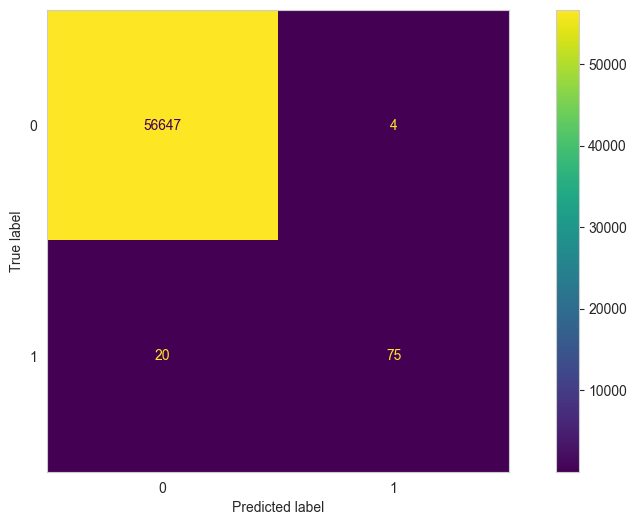

In [37]:
# Print and visualise confusion matrix for XGBoost test results
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

cm_display = ConfusionMatrixDisplay(cm).plot()
cm_display.ax_.grid(False)
print(cm_display)

In [38]:
# Put the code here
# Test Set Metrics: PR-AUC, Precision, Recall, F1, False Positive Rate

# Assuming y_test, y_pred, y_proba are available from previous XGBoost evaluation
# Calculate metrics
pr_auc = average_precision_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate False Positive Rate from confusion matrix
# FPR = FP / (FP + TN)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

# Display results
print("=" * 50)
print("TEST SET EVALUATION METRICS")
print("=" * 50)
print(f"PR-AUC:              {pr_auc:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")
print(f"F1-Score:            {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print("=" * 50)

# Additional context
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")

TEST SET EVALUATION METRICS
PR-AUC:              0.8315
Precision:           0.9494
Recall:              0.7895
F1-Score:            0.8621
False Positive Rate: 0.0001

Confusion Matrix Breakdown:
  True Negatives:  56,647
  False Positives: 4
  False Negatives: 20
  True Positives:  75


In [39]:
# QUICK TEST: XGBoost with Top 10 Features

# Top 10 features by absolute correlation with Class
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

# Select features (use no_scale or std - doesn't matter for XGBoost)
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Use your best XGBoost params
xgb_top = XGBClassifier(
    scale_pos_weight=599,
    max_depth=9,
    learning_rate=0.2,
    n_estimators=300,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

xgb_top.fit(X_train_top, y_train)
y_proba_top = xgb_top.predict_proba(X_test_top)[:, 1]
pr_auc_top = average_precision_score(y_test, y_proba_top)

print(f"XGBoost (all 30 features): PR-AUC 0.8315")
print(f"XGBoost (top 10 features): PR-AUC {pr_auc_top:.4f}")
print(f"Difference: {(pr_auc_top - 0.8315)*100:.2f}%")

XGBoost (all 30 features): PR-AUC 0.8315
XGBoost (top 10 features): PR-AUC 0.7774
Difference: -5.41%


In [ ]:
# # XGBoost wtih robust scaling (no resampling)

print("="*70)
print("HYPERPARAMETER TUNING: XGBoost")
print("="*70)

# Base model
xgb_rob = XGBClassifier(
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='aucpr'
)

# Run search
start_time = time.time()
search2 = RandomizedSearchCV(
    xgb_rob, 
    param_dist, 
    n_iter=30, 
    cv=5,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search2.fit(X_train_rob, y_train)
elapsed = time.time() - start_time

# Results
print(f"\n{'='*70}")
print("TUNING RESULTS")
print(f"{'='*70}")
print(f"Time elapsed: {elapsed:.1f} seconds")
print(f"\nBest CV PR-AUC: {search2.best_score_:.4f}")
print(f"Baseline PR-AUC: {BASELINE_PR_AUC:.4f}")
print(f"Improvement: {(search2.best_score_ - BASELINE_PR_AUC) * 100:.2f}%")

print(f"\nBest Parameters:")
for param, value in search2.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate on test set
best_xgb_rob = search2.best_estimator_
y_pred_rob = best_xgb_rob.predict(X_test)
y_proba_rob = best_xgb_rob.predict_proba(X_test)[:, 1]
test_pr_auc_rob = average_precision_score(y_test, y_proba_rob)

print(f"\n{'='*70}")
print("TEST SET EVALUATION")
print(f"{'='*70}")
print(f"Test PR-AUC: {test_pr_auc_rob:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rob, target_names=['Normal', 'Fraud']))
print("="*70)

HYPERPARAMETER TUNING: XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

TUNING RESULTS
Time elapsed: 112.9 seconds

Best CV PR-AUC: 0.8567
Baseline PR-AUC: 0.8230
Improvement: 3.37%

Best Parameters:
  subsample: 0.9
  n_estimators: 300
  max_depth: 9
  learning_rate: 0.2
  colsample_bytree: 0.9

TEST SET EVALUATION
Test PR-AUC: 0.8161

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.95      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



Much worse score doing parameter distribution on Robust Scaler (0.8161) vs Standard Scaler (0.8315)

missed 5 more false negatives [actual fraud] as well as 5 true positives [actual fraud]


Confusion Matrix:
 [[56647     4]
 [   25    70]]


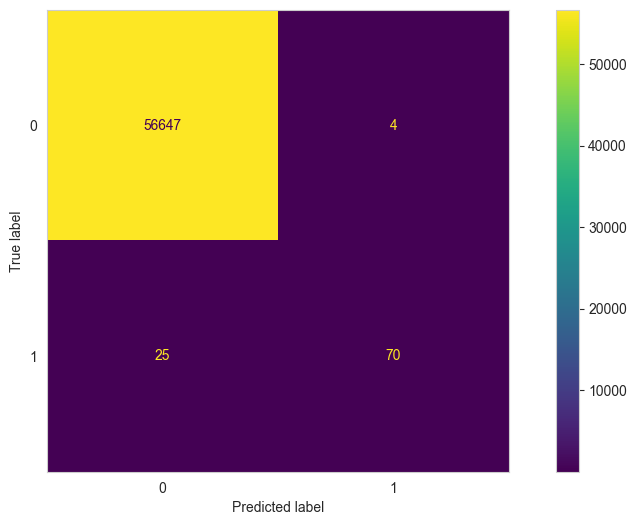

In [30]:
# Print and visualise confusion matrix for XGBoost test results
cm_rob = confusion_matrix(y_test, y_pred_rob)
print('Confusion Matrix:\n', cm_rob)

cm_display_rob = ConfusionMatrixDisplay(cm_rob).plot()
cm_display_rob.ax_.grid(False)
print(cm_display_rob)

## 6.2 RandomForest

As we saw ealier in the notebook when comparing models and resampling methods, Random Forest performed best with SMOTE. We will try to improve this baseline model

**Decision**: RF + SMOTE tuning skipped due to computational constraints (8GB RAM, SMOTE expansion).

Baseline comparison showed:
- XGBoost (No Resampling): PR-AUC 0.8315 ✓ **WINNER**
- RF + SMOTE (untuned): PR-AUC 0.8178

Given XGBoost's superior performance and RF's computational cost with SMOTE,
**XGBoost is selected as the final model.**

**Scaling Comparison**:

Standard Scaling performs better than Robust Scaling

Standard Scaler = less false positives (by 4), the rest is the same
<br></br>
Looking at PR-AUC

- Std = 0.8178
- Rob = 0.8094

Standard scaler outperforms on every metric

### Baseline Random Forest Model

In [40]:
# Hyperparameter tuning - Random Forest
# Test on standard scaled test set
rf_model_std = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1)
rf_model_std.fit(X_train_smote, y_train_smote)

# Predictions (standard scaled test set)
y_pred_rf_std = rf_model_std.predict(X_test_std)
y_proba_rf_std = rf_model_std.predict_proba(X_test_std)[:, 1]
print(accuracy_score(y_test, y_pred_rf_std))

0.9994713283755683


In [43]:
# Print ROC-AUC, classification report, confusion matrix, and compute PR-AUC 

# 1. Print metrics and diagnostics
print(roc_auc_score(y_test, y_proba_rf_std))
print(classification_report(y_test, y_pred_rf_std))
print(confusion_matrix(y_test, y_pred_rf_std))

roc_auc_rf_std = roc_auc_score(y_test, y_proba_rf_std)
accuracy_rf_std = accuracy_score(y_test, y_pred_rf_std)
precision_rf_std = precision_score(y_test, y_pred_rf_std)
recall_rf_std = recall_score(y_test, y_pred_rf_std)
f1_rf_std = f1_score(y_test, y_pred_rf_std)

print(f"\nROC-AUC: {roc_auc_rf_std:.4f}")
print(f"Accuracy: {accuracy_rf_std:.4f}")
print(f"Precision: {precision_rf_std:.4f}")
print(f"Recall: {recall_rf_std:.4f}")
print(f"F1-Score: {f1_rf_std:.4f}")

# 2. PR-AUC calculation: best practice is to use predicted probabilities, not the thresholded y_pred

pr_precisions_std, pr_recalls_std, _ = precision_recall_curve(y_test, y_proba_rf_std)
pr_auc_std = auc(pr_recalls_std, pr_precisions_std)
print(f"PR-AUC: {pr_auc_std:.4f}")

# Note:
# - It is **incorrect** to compute PR-AUC with just scalar values of precision/recall from the class report.
# - The PR-AUC should be calculated using the precision-recall pairs generated by varying the threshold over y_proba.
# - This follows scikit-learn doc and best practices.

0.9662031329404691
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

[[56644     7]
 [   23    72]]

ROC-AUC: 0.9662
Accuracy: 0.9995
Precision: 0.9114
Recall: 0.7579
F1-Score: 0.8276
PR-AUC: 0.8178


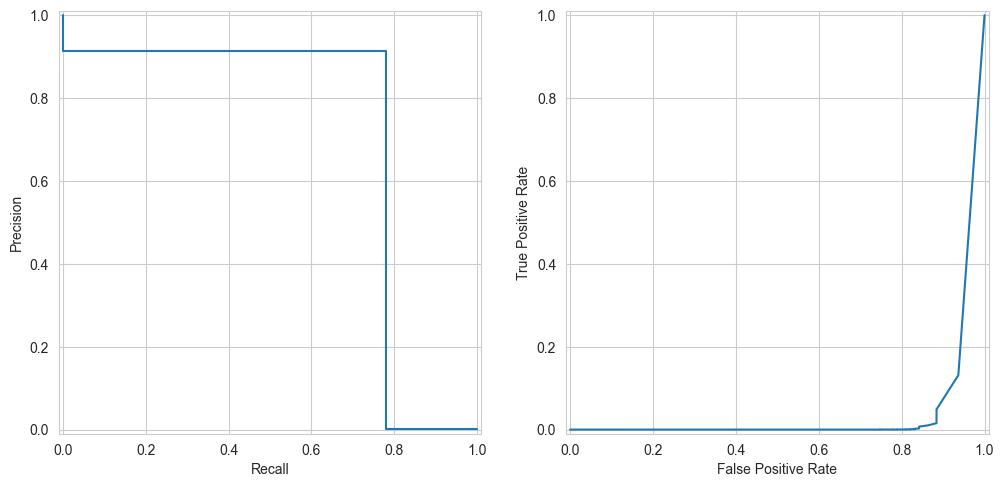

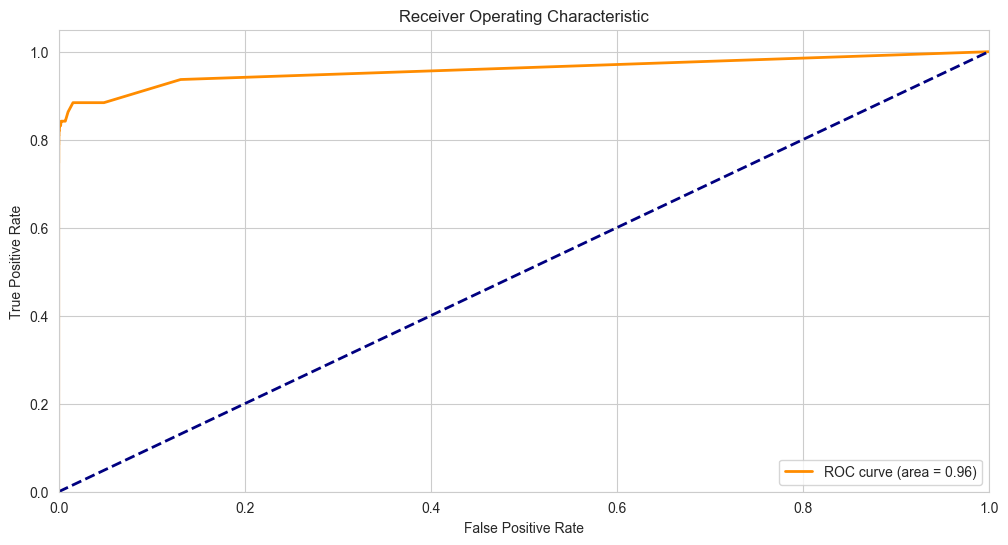

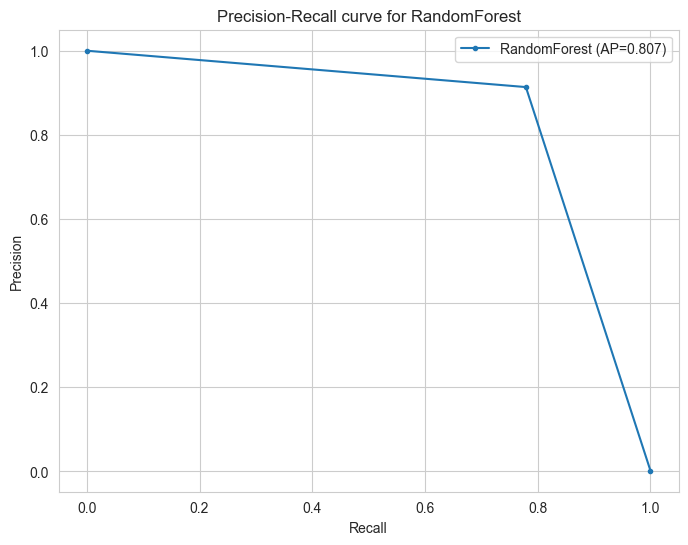

In [ ]:
# Calculate average precision score
average_precision = average_precision_score(y_test, y_proba)
# Obtain precision and recall 
precision, recall, _ = precision_recall_curve(y_test, y_pred)

pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)

tpr, fpr, _ = roc_curve(y_test, y_proba)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

pr_display.plot(ax=ax1)
roc_display.plot(ax=ax2)
plt.show()

# Plotting the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot the recall precision tradeoff

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='RandomForest (AP={:.3f})'.format(average_precision))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve for RandomForest')
plt.legend()
plt.grid(True)
plt.show()



### Random Forest Using Pipeline

attempted but takes too long to run (1 hour and no output)

In [47]:
## RF + SMOTE Hyperparameter Tuning (Pipeline)

print("="*70)
print("HYPERPARAMETER TUNING: Random Forest + SMOTE (Pipeline)")
print("="*70)

# Baselines to beat
RF_SMOTE_BASELINE = 0.8178
XGBOOST_PR_AUC = 0.8315

# Create pipeline: SMOTE → RandomForest
# SMOTE will be applied INSIDE each CV fold (no data leakage)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

# Parameter distribution (prefix with 'rf__' for pipeline)
param_dist_rf_pipeline = {
    'rf__n_estimators': [100, 200, 300, 400],
    'rf__max_depth': [10, 15, 20, 25, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None],
}

print(f"Pipeline: SMOTE → RandomForest")
print(f"Search space: {len(param_dist_rf_pipeline)} parameter groups")
print(f"RandomizedSearchCV: n_iter=30, cv=5\n")

# Run search
start_time = time.time()
search_pipeline = RandomizedSearchCV(
    pipeline,
    param_dist_rf_pipeline,
    n_iter=20,
    cv=5,
    scoring='average_precision',  # PR-AUC
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Use ORIGINAL X_train (not pre-resampled) - SMOTE happens inside CV
search_pipeline.fit(X_train, y_train)
elapsed = time.time() - start_time

# Results
print(f"\n{'='*70}")
print("TUNING RESULTS")
print(f"{'='*70}")
print(f"Time elapsed: {elapsed:.1f} seconds")
print(f"\nBest CV PR-AUC: {search_pipeline.best_score_:.4f}")
print(f"RF Baseline PR-AUC: {RF_SMOTE_BASELINE:.4f}")
print(f"XGBoost PR-AUC: {XGBOOST_PR_AUC:.4f}")

print(f"\nBest Parameters:")
for param, value in search_pipeline.best_params_.items():
    print(f"  {param}: {value}")


HYPERPARAMETER TUNING: Random Forest + SMOTE (Pipeline)
Pipeline: SMOTE → RandomForest
Search space: 5 parameter groups
RandomizedSearchCV: n_iter=30, cv=5

Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# TEST SET EVALUATION - Tuned Random Forest
# ============================================================================

# Get best pipeline
best_rf_pipeline = search.best_estimator_

# Predict on test set (no SMOTE on test - just prediction)
y_pred_rf = best_rf_pipeline.predict(X_test)
y_proba_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]
test_pr_auc_rf = average_precision_score(y_test, y_proba_rf)

print(f"{'='*70}")
print("TEST SET EVALUATION - Tuned Random Forest + SMOTE")
print(f"{'='*70}")
print(f"Test PR-AUC: {test_pr_auc_rf:.4f}")
print(f"XGBoost Test PR-AUC: {XGBOOST_PR_AUC:.4f}")
print(f"Difference: {(test_pr_auc_rf - XGBOOST_PR_AUC)*100:.2f}%")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
tn, fp, fn, tp = cm.ravel()
print(f"\nFalse Positives: {fp}, False Negatives: {fn}")
print("="*70)

# Store for comparison
tuned_rf_pr_auc = test_pr_auc_rf

### Subsample

In [42]:
# Define the model with balanced subsample
model = RandomForestClassifier(class_weight='balanced_subsample', random_state=5, n_estimators=100)
# Test on standard scaled test set

# Fit your training model to your training set
model.fit(X_train_none, y_train_none)

# Obtain the predicted values and probabilities from the model 
predicted = model.predict(X_test)
probs = model.predict_proba(X_test)

# Print the ROC curve, classification report and confusion matrix
print('ROC Score:')
print(roc_auc_score(y_test, probs[:,1]))
print('\nClassification Report:')
print(classification_report(y_test, predicted))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, predicted))


roc_auc = roc_auc_score(y_test, probs[:,1])
accuracy = accuracy_score(y_test, predicted)
precision = precision_score(y_test, predicted)
recall = recall_score(y_test, predicted)
f1 = f1_score(y_test, predicted)

print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 2. PR-AUC calculation: best practice is to use predicted probabilities, not the thresholded y_pred

pr_precisions, pr_recalls, _ = precision_recall_curve(y_test, probs[:,1])
pr_auc = auc(pr_recalls, pr_precisions)
print(f"PR-AUC: {pr_auc:.4f}")


ROC Score:
0.9298733055299809

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56650     1]
 [   28    67]]

ROC-AUC: 0.9299
Accuracy: 0.9995
Precision: 0.9853
Recall: 0.7053
F1-Score: 0.8221
PR-AUC: 0.8177


## 6.3 Logistic Regression

In [ ]:
# LOGISTIC REGRESSION + SMOTE: EVALUATION FOR ENSEMBLE CONSIDERATION
# Test on standard scaled test set
print("="*70)
print("LOGISTIC REGRESSION + SMOTE: DETAILED EVALUATION")
print("="*70)

# Get SMOTE data and train
X_train_smote_data, y_train_smote_data = resampled_datasets['SMOTE']

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)
lr_model.fit(X_train_smote_data, y_train_smote_data)

# Predictions (standard scaled test set)
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()

# Calculate all metrics
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
fpr_lr = fp / (fp + tn)  # False Positive Rate

# PR-AUC
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_lr)
pr_auc = auc(rec_curve, prec_curve)

# Print Results
print("\n1. CLASSIFICATION REPORT:")
print("-"*70)
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))

print("\n2. CONFUSION MATRIX:")
print("-"*70)
print(f"                    Predicted")
print(f"                 Normal   Fraud")
print(f"Actual  Normal   {tn:6d}  {fp:6d}")
print(f"        Fraud    {fn:6d}  {tp:6d}")

print("\n3. KEY METRICS:")
print("-"*70)
print(f"  Precision:           {precision:.4f}  ({precision*100:.1f}% of fraud predictions correct)")
print(f"  Recall:              {recall:.4f}  ({recall*100:.1f}% of actual fraud caught)")
print(f"  F1-Score:            {f1:.4f}")
print(f"  ROC-AUC:             {roc_auc:.4f}")
print(f"  PR-AUC:              {pr_auc:.4f}")
print(f"  False Positive Rate: {fpr:.4f}  ({fp:,} normal transactions flagged as fraud)")

print("\n4. COMPARISON TO XGBOOST:")
print("-"*70)
print(f"  {'Metric':<20} {'LogReg+SMOTE':>12} {'XGBoost':>12} {'Winner':>10}")
print(f"  {'-'*54}")
print(f"  {'Precision':<20} {precision:>12.4f} {0.95:>12.4f} {'XGBoost':>10}")
print(f"  {'Recall':<20} {recall:>12.4f} {0.79:>12.4f} {'LogReg':>10}")
print(f"  {'F1-Score':<20} {f1:>12.4f} {0.86:>12.4f} {'XGBoost':>10}")
print(f"  {'PR-AUC':<20} {pr_auc:>12.4f} {0.8315:>12.4f} {'XGBoost':>10}")
print(f"  {'False Positives':<20} {fp:>12,} {4:>12,} {'XGBoost':>10}")
print("="*70)

LOGISTIC REGRESSION + SMOTE: DETAILED EVALUATION

1. CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


2. CONFUSION MATRIX:
----------------------------------------------------------------------
                    Predicted
                 Normal   Fraud
Actual  Normal    55169    1482
        Fraud        12      83

3. KEY METRICS:
----------------------------------------------------------------------
  Precision:           0.0530  (5.3% of fraud predictions correct)
  Recall:              0.8737  (87.4% of actual fraud caught)
  F1-Score:            0.1000
  ROC-AUC:             0.9619
  PR-AUC:              0.7150


In [31]:
# Detailed Evaluation: Logistic Regression with SMOTE
print("="*70)
print("LOGISTIC REGRESSION WITH SMOTE - DETAILED EVALUATION")
print("="*70)

# Get the best performing Logistic Regression with SMOTE
# Extract SMOTE data from resampled_datasets
X_train_data, y_train_data = resampled_datasets['SMOTE']

# Train Logistic Regression with SMOTE
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)
lr_smote.fit(X_train_data, y_train_data)

# Predictions
y_pred_lr = lr_smote.predict(X_test)
y_proba_lr = lr_smote.predict_proba(X_test)[:, 1]

# Classification Report
print("\n1. CLASSIFICATION REPORT:")
print("-" * 70)
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))



LOGISTIC REGRESSION WITH SMOTE - DETAILED EVALUATION

1. CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746




2. CONFUSION MATRIX:
----------------------------------------------------------------------
Confusion Matrix:
 [[55169  1482]
 [   12    83]]


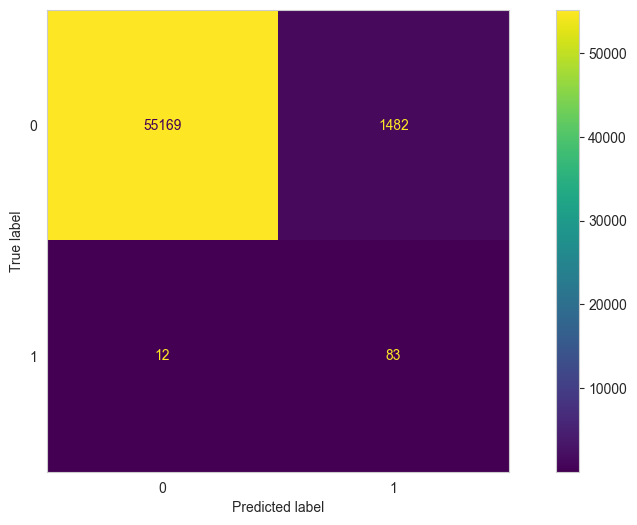

In [33]:
# Confusion Matrix - Visual
print("\n2. CONFUSION MATRIX:")
print("-" * 70)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print('Confusion Matrix:\n', cm_lr)

cm_display_lr = ConfusionMatrixDisplay(cm_lr).plot()
cm_display_lr.ax_.grid(False)
print(cm_display_lr)



In [28]:
# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Values:")
print(f"                    Predicted")
print(f"                 Normal   Fraud")
print(f"Actual  Normal    {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"        Fraud     {cm[1,0]:6d}  {cm[1,1]:6d}")

print(f"\nInterpretation:")
print(f"  True Negatives (TN):  {tn:6d} - Correctly identified normal transactions")
print(f"  False Positives (FP): {fp:6d} - Normal transactions flagged as fraud (Type I Error)")
print(f"  False Negatives (FN): {fn:6d} - Fraud transactions missed (Type II Error)")
print(f"  True Positives (TP):  {tp:6d} - Correctly identified fraud transactions")




Confusion Matrix Values:
                    Predicted
                 Normal   Fraud
Actual  Normal     55169    1482
        Fraud         12      83

Interpretation:
  True Negatives (TN):   55169 - Correctly identified normal transactions
  False Positives (FP):   1482 - Normal transactions flagged as fraud (Type I Error)
  False Negatives (FN):     12 - Fraud transactions missed (Type II Error)
  True Positives (TP):      83 - Correctly identified fraud transactions


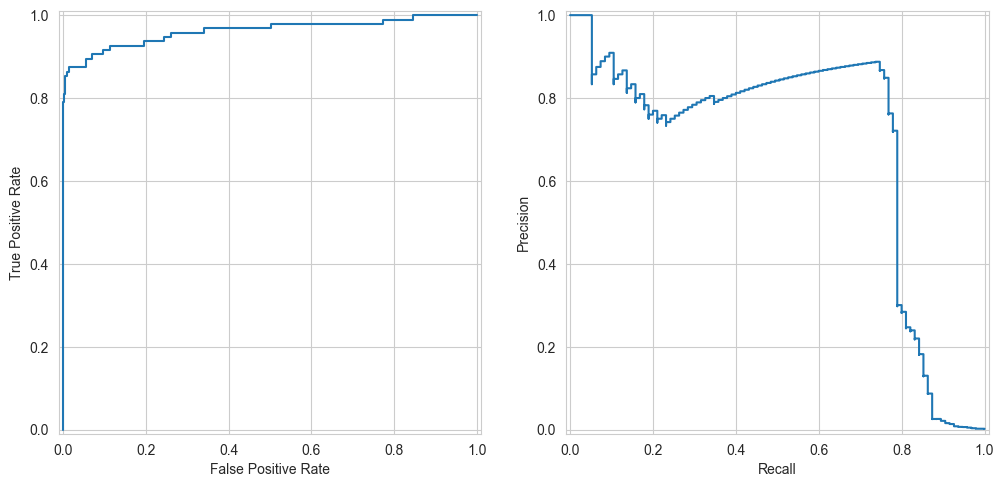

In [ ]:
# Plot ROC curve
y_score = lr_smote.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=lr_smote.classes_[1])
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)

# Plot precision recall curve
prec, recall, _ = precision_recall_curve(y_test, y_score, pos_label=lr_smote.classes_[1])
pr_display = PrecisionRecallDisplay(precision=prec, recall=recall)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

roc_display.plot(ax=ax1)
pr_display.plot(ax=ax2)
plt.show()




Text(0.5, 1.0, '2-class Precision-Recall curve')
Text(0.5, 1.0, '2-class Precision-Recall curve')


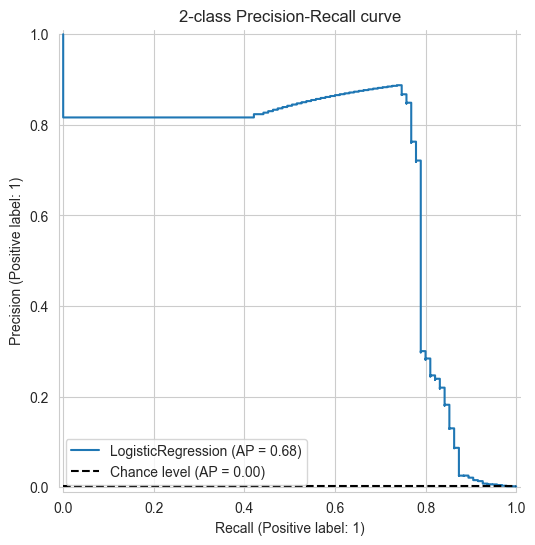

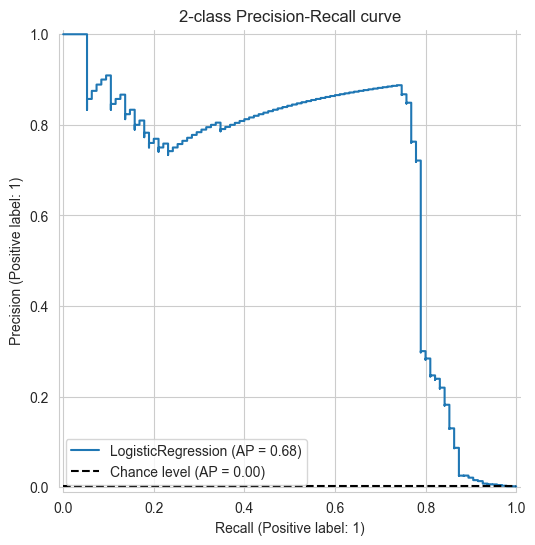

In [ ]:
# Plot precision recall curve
display = PrecisionRecallDisplay.from_estimator(
    lr_smote, X_test, y_test, name="LogisticRegression", plot_chance_level=True, despine=True
)
print(display.ax_.set_title("2-class Precision-Recall curve"))

y_score = lr_smote.decision_function(X_test)

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_score, name="LogisticRegression", plot_chance_level=True, despine=True
)
print(display.ax_.set_title("2-class Precision-Recall curve"))



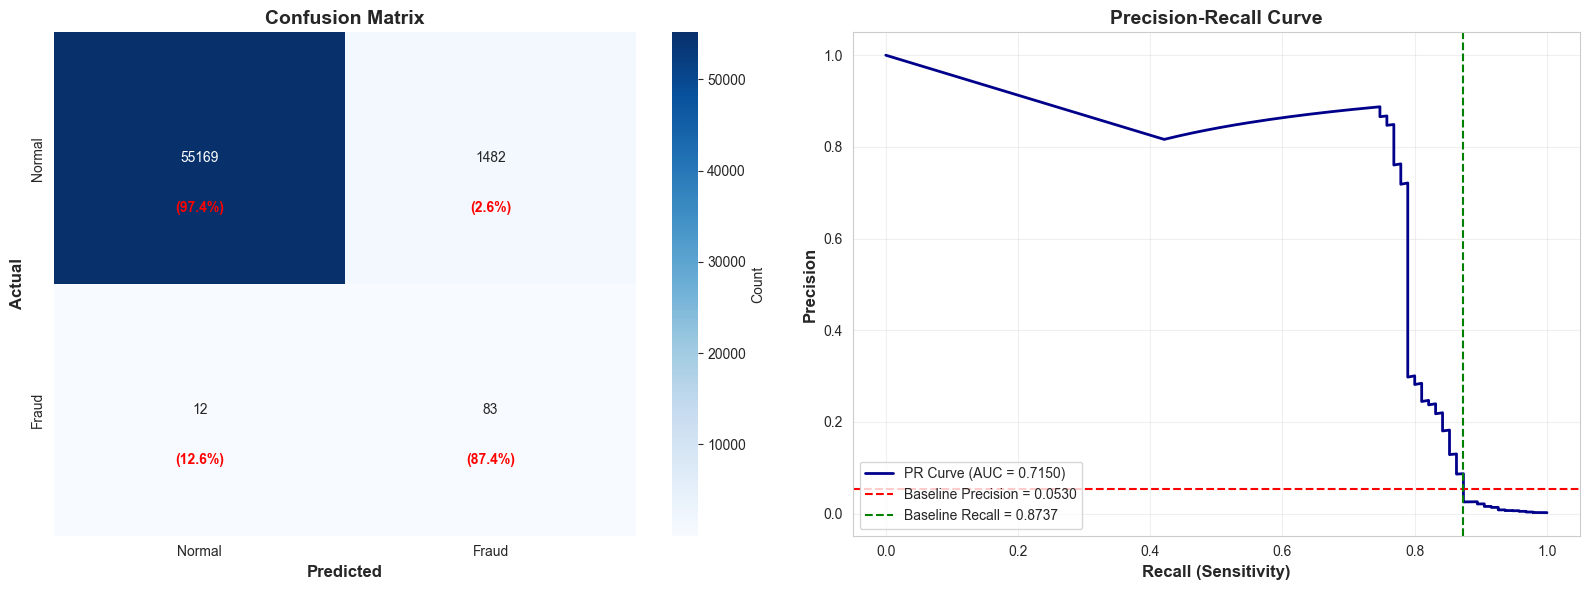

In [31]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add percentage annotations
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
for i in range(2):
    for j in range(2):
        ax1.text(j+0.5, i+0.7, f'({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=10, color='red', fontweight='bold')


# Precision-Recall Curve
ax2 = axes[1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lr)
pr_auc = auc(recall, precision)

ax2.plot(recall, precision, color='darkblue', lw=2, 
         label=f'PR Curve (AUC = {pr_auc:.4f})')
ax2.axhline(y=tp/(tp+fp), color='r', linestyle='--', 
           label=f'Baseline Precision = {tp/(tp+fp):.4f}')
ax2.axvline(x=tp/(tp+fn), color='g', linestyle='--', 
           label=f'Baseline Recall = {tp/(tp+fn):.4f}')
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [32]:
# Additional Metrics
print(f"\n4. ADDITIONAL METRICS:")
print("-" * 70)
roc_auc = roc_auc_score(y_test, y_proba_lr)

print(f"  ROC-AUC:  {roc_auc:.4f}")
print(f"  PR-AUC:   {pr_auc:.4f}")
print(f"  Precision: {tp / (tp + fp):.4f} (from confusion matrix)")
print(f"  Recall:    {tp / (tp + fn):.4f} (from confusion matrix)")
print(f"  F1-Score:  {2 * tp / (2 * tp + fp + fn):.4f}")


4. ADDITIONAL METRICS:
----------------------------------------------------------------------
  ROC-AUC:  0.9619
  PR-AUC:   0.7150
  Precision: 0.0530 (from confusion matrix)
  Recall:    0.8737 (from confusion matrix)
  F1-Score:  0.1000



1. CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.95     56651
       Fraud       0.02      0.89      0.03        95

    accuracy                           0.91     56746
   macro avg       0.51      0.90      0.49     56746
weighted avg       1.00      0.91      0.95     56746


2. CONFUSION MATRIX:
----------------------------------------------------------------------
Confusion Matrix:
 [[51680  4971]
 [   10    85]]


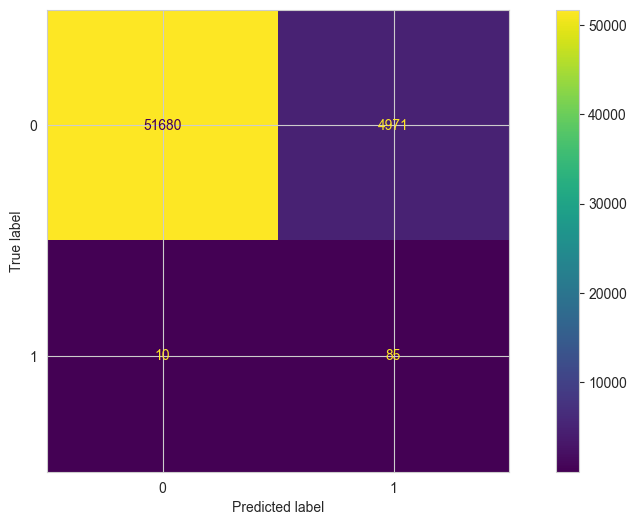

In [ ]:
# Detailed Evaluation: Logistic Regression with SMOTE
# Train Logistic Regression with SMOTE
# Test on robust scaled test set

lr_smote2 = LogisticRegression(
    random_state=1,
    class_weight={0:1, 1:4},
)
lr_smote2.fit(X_train_lr_smote, y_train_lr_smote)

# Predictions (robust scaled test set)
y_pred_lr_smote = lr_smote2.predict(X_test_rob)
y_proba_lr_smote = lr_smote2.predict_proba(X_test_rob)[:, 1]

# Classification Report
print("\n1. CLASSIFICATION REPORT:")
print("-" * 70)
print(classification_report(y_test, y_pred_lr_smote, target_names=['Normal', 'Fraud']))

# Confusion Matrix - Visual
print("\n2. CONFUSION MATRIX:")
print("-" * 70)
cm = confusion_matrix(y_test, y_pred_lr_smote)
print('Confusion Matrix:\n', cm)

# Plot confusion matrix
cm_display = ConfusionMatrixDisplay(cm).plot()
cm_display.ax_.grid(False)
print(cm_display)

Robust takes the 2 missed (false negative) and actually captures (true positive ~ actual fraud). BUT flags a whole lot more false positives (incorrect fraud). This is bad for customer sentiment by ~3x, so not worth using Robust scaler.

In [ ]:
# IMPROVEMENT ANALYSIS: Logistic Regression with SMOTE

print("="*70)
print("IMPROVEMENT OPPORTUNITIES FOR LOGISTIC REGRESSION WITH SMOTE")
print("="*70)

# Calculate all metrics
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
# PR-AUC
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_lr)
pr_auc = auc(rec_curve, prec_curve)



# Get exact values from results_df
lr_smote_result = results_df[(results_df['Model'] == 'LogisticRegression') & 
                              (results_df['Resampling'] == 'SMOTE')].iloc[0]

print("\n1. CURRENT PERFORMANCE SUMMARY:")
print("-" * 70)
print(f"  ROC-AUC:  {lr_smote_result['ROC-AUC']:.4f}  (Excellent - near perfect)")
print(f"  PR-AUC:   {lr_smote_result['PR-AUC']:.4f}  (Moderate - good but can be improved)")
print(f"  Recall:   {lr_smote_result['Recall']:.4f}  (High - catches {lr_smote_result['Recall']*100:.1f}% of fraud)")
print(f"  Precision: {lr_smote_result['Precision']:.4f}  (Very Low - only {lr_smote_result['Precision']*100:.1f}% of flagged cases are fraud)")
print(f"  F1-Score:  {lr_smote_result['F1-Score']:.4f}  (Low due to precision/recall imbalance)")



IMPROVEMENT OPPORTUNITIES FOR LOGISTIC REGRESSION WITH SMOTE

1. CURRENT PERFORMANCE SUMMARY:
----------------------------------------------------------------------
  ROC-AUC:  0.9619  (Excellent - near perfect)
  PR-AUC:   0.7150  (Moderate - good but can be improved)
  Recall:   0.8737  (High - catches 87.4% of fraud)
  Precision: 0.0530  (Very Low - only 5.3% of flagged cases are fraud)
  F1-Score:  0.1000  (Low due to precision/recall imbalance)


# 7. Ensemble Methods

Test if combining XGBoost with RF improves performance.

In [49]:
# Model ensemble/stacking

# Use your tuned models
ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf_model_std)
    ],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_proba_ens = ensemble.predict_proba(X_test)[:, 1]
pr_auc_ens = average_precision_score(y_test, y_proba_ens)

print(f"XGBoost alone: 0.8315")
print(f"RF alone:      0.8174")
print(f"Ensemble:      {pr_auc_ens:.4f}")

XGBoost alone: 0.8315
RF alone:      0.8174
Ensemble:      0.8063


In [ ]:
# Side-by-side metrics comparison (all models)


In [ ]:
# Hyperparameter differences analysis

In [ ]:
# Performance visualization (comprehensive charts)

In [ ]:
# Trade-offs summary and recommendations

In [ ]:
# Final conclusions

# 8. Final Evaluation & Conclusions

## Conclusion & Next Steps
### Summary
| Aspect | Finding |
|--------|----------|
| Best Model | XGBoost with `scale_pos_weight` |
| Resampling | Not needed (class weights sufficient) |
| Scaling | StandardScaler (Time & Amount only) |
| PR-AUC | 0.83 (strong for fraud detection) |
| Business Impact | 95% precision, 79% recall |
       
### Key Learnings
1. **PR-AUC > ROC-AUC** for imbalanced classification
2. **XGBoost's `scale_pos_weight`** handles imbalance better than SMOTE
3. **Duplicates removal** improved data quality (3.86% fraud duplicates vs 0.37% normal)
4. **Scaling matters less** for tree-based models, but helps for consistency
       
### Next Steps
    

1. **Threshold optimization**: Analyze precision-recall tradeoff for business requirements
2. **Integration**: Deploy model in real-time fraud detection pipeline
3. **Monitoring**: Track model performance and detect concept drift
4. **Retraining**: Establish periodic retraining schedule
    